In [2]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from matplotlib.animation import FuncAnimation, PillowWriter

ذخیره شد در: /mnt/f/test/network_hub_star.png


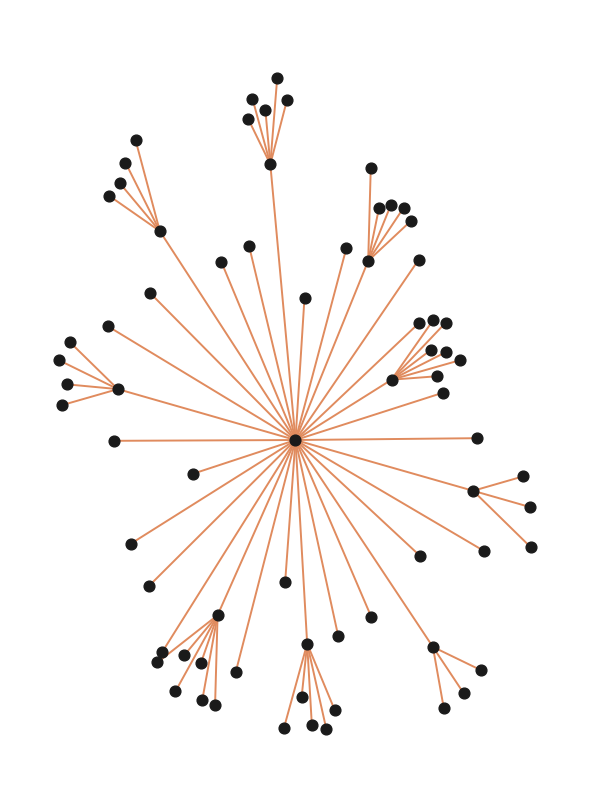

In [3]:
OUTPUT_DIR = r"/mnt/f/test/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

rng = np.random.default_rng(7)

EDGE_COLOR = "#E08B5E"
NODE_COLOR = "#1a1a1a"
NODE_SIZE = 60
EDGE_WIDTH = 1.4

def build_hub_star_network(n_branches=30, n_clusters=9, satellite_range=(3, 7), min_cluster_gap=3):
    """
    n_branches      : تعداد کل شاخه‌های متصل به هاب مرکزی
    n_clusters      : تعداد شاخه‌هایی که خوشه ماهواره‌ای می‌گیرند
    satellite_range : بازه تعداد گره‌های هر خوشه
    min_cluster_gap : حداقل فاصله‌ی ایندکسی بین شاخه‌های خوشه‌دار
    """
    G = nx.Graph()
    pos = {}

    center = "hub"
    G.add_node(center)
    pos[center] = (0.0, 0.0)

    base_angles = np.linspace(0, 2 * np.pi, n_branches, endpoint=False)
    jitter = rng.uniform(-0.03, 0.03, n_branches)
    angles = base_angles + jitter

    radii = rng.choice([3.5, 5.0, 6.0, 6.8], size=n_branches, p=[0.15, 0.30, 0.35, 0.20])

    cluster_branches = []
    candidates = list(range(n_branches))
    rng.shuffle(candidates)
    for c in candidates:
        if all(min(abs(c - x), n_branches - abs(c - x)) >= min_cluster_gap
               for x in cluster_branches):
            cluster_branches.append(c)
        if len(cluster_branches) >= n_clusters:
            break

    for i, theta in enumerate(angles):
        node = f"b{i}"
        r = radii[i]
        x, y = r * np.cos(theta), r * np.sin(theta)
        G.add_node(node)
        pos[node] = (x, y)
        G.add_edge(center, node)

        if i in cluster_branches:
            n_sat = rng.integers(*satellite_range)
            spread = rng.uniform(0.35, 0.55)
            sat_angles = np.linspace(theta - spread, theta + spread, n_sat)
            for j, sa in enumerate(sat_angles):
                sat = f"b{i}_s{j}"
                dr = rng.uniform(1.3, 2.4)
                sx = x + dr * np.cos(sa)
                sy = y + dr * np.sin(sa)
                G.add_node(sat)
                pos[sat] = (sx, sy)
                G.add_edge(node, sat)

    return G, pos

def stretch_vertically(pos, factor=1.35):
    return {k: (x, y * factor) for k, (x, y) in pos.items()}

G1, pos1 = build_hub_star_network()
pos1 = stretch_vertically(pos1, factor=1.35)

fig, ax = plt.subplots(figsize=(6, 11))
nx.draw_networkx_edges(G1, pos1, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
nx.draw_networkx_nodes(G1, pos1, ax=ax, node_color=NODE_COLOR, node_size=NODE_SIZE)
#ax.set_title("Hub / Radial Star Network", fontsize=12)
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "network_hub_star.png")
fig.savefig(save_path, dpi=200, facecolor="white", bbox_inches="tight")
print("ذخیره شد در:", save_path)

plt.show()

['hub', 'b0', 'b1', 'b2', 'b2_s0', 'b2_s1', 'b2_s2', 'b2_s3', 'b2_s4', 'b2_s5', 'b3', 'b4', 'b5', 'b5_s0', 'b5_s1', 'b5_s2', 'b5_s3', 'b5_s4', 'b6', 'b7', 'b8', 'b8_s0', 'b8_s1', 'b8_s2', 'b8_s3', 'b8_s4', 'b9', 'b10', 'b11', 'b11_s0', 'b11_s1', 'b11_s2', 'b11_s3', 'b12', 'b13', 'b14', 'b14_s0', 'b14_s1', 'b14_s2', 'b14_s3', 'b15', 'b16', 'b17', 'b18', 'b19', 'b20', 'b20_s0', 'b20_s1', 'b20_s2', 'b20_s3', 'b20_s4', 'b20_s5', 'b21', 'b22', 'b23', 'b23_s0', 'b23_s1', 'b23_s2', 'b23_s3', 'b23_s4', 'b24', 'b25', 'b26', 'b26_s0', 'b26_s1', 'b26_s2', 'b27', 'b28', 'b29', 'b29_s0', 'b29_s1', 'b29_s2']


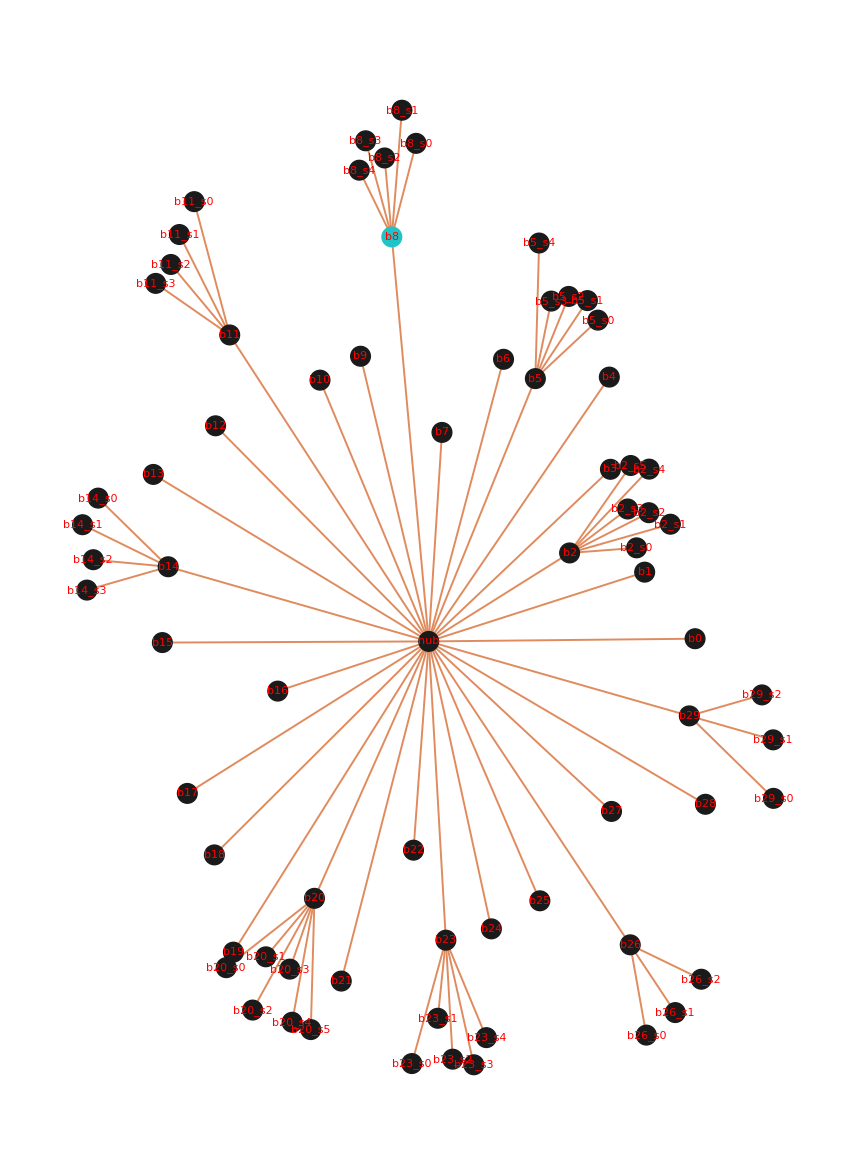

In [4]:
fig, ax = plt.subplots(figsize=(12, 15))

active_test = {"b8"}

nx.draw_networkx_edges(G1, pos1, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
nx.draw_networkx_nodes(G1, pos1, ax=ax, node_color=["#20C4C7" if n in active_test else NODE_COLOR for n in G1.nodes()], node_size=200)
nx.draw_networkx_labels(G1, pos1, ax=ax, font_size=8, font_color="red")

print(G1.nodes())

ax.set_aspect("equal")
ax.axis("off")
plt.show()

ذخیره شد در: /mnt/f/test/network_clustered_mesh.png


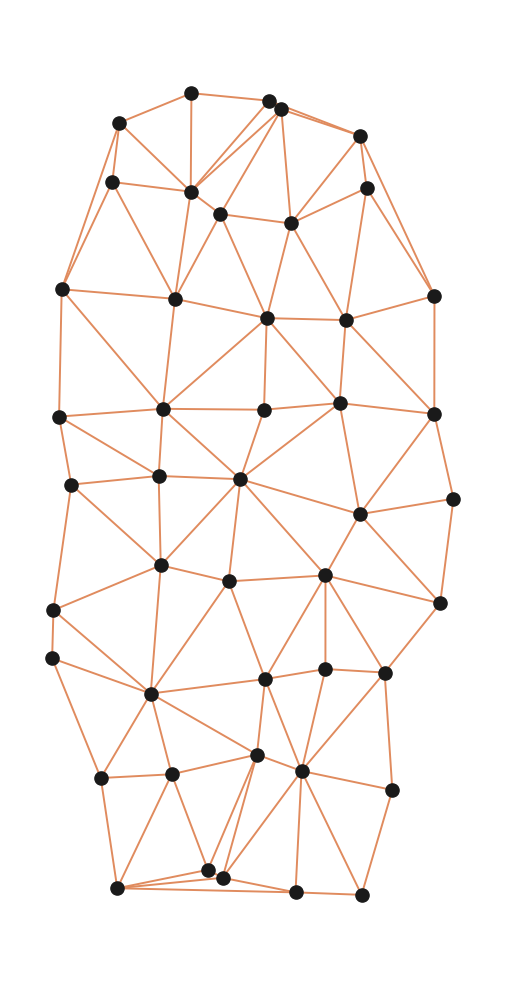

In [5]:
OUTPUT_DIR = r"/mnt/f/test/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EDGE_COLOR = "#E08B5E"
NODE_COLOR = "#1a1a1a"
NODE_SIZE = 90
EDGE_WIDTH = 1.4

def build_clustered_mesh_network(n_points=42, jitter=0.28, max_edge_len=1.9, seed=3):
    r = np.random.default_rng(seed)

    pts = []
    rows, cols = 9, 5
    for i in range(rows):
        for j in range(cols):
            row_frac = i / (rows - 1)
            width_scale = 0.55 + 0.45 * np.sin(np.pi * row_frac)
            x = (j - (cols - 1) / 2) * width_scale
            y = i
            x += r.uniform(-jitter, jitter)
            y += r.uniform(-jitter, jitter)
            pts.append((x, y))
    pts = np.array(pts)

    tri = Delaunay(pts)
    G = nx.Graph()
    pos = {}
    for idx, (x, y) in enumerate(pts):
        G.add_node(idx)
        pos[idx] = (x, y)

    for simplex in tri.simplices:
        for a, b in [(0, 1), (1, 2), (0, 2)]:
            u, v = simplex[a], simplex[b]
            d = np.linalg.norm(pts[u] - pts[v])
            if d <= max_edge_len:
                G.add_edge(int(u), int(v))

    return G, pos

G2, pos2 = build_clustered_mesh_network()

fig, ax = plt.subplots(figsize=(6, 10))
nx.draw_networkx_edges(G2, pos2, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
nx.draw_networkx_nodes(G2, pos2, ax=ax, node_color=NODE_COLOR, node_size=NODE_SIZE)
#ax.set_title("Clustered Mesh Network", fontsize=12)
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "network_clustered_mesh.png")
fig.savefig(save_path, dpi=200, facecolor="white", bbox_inches="tight")
print("ذخیره شد در:", save_path)

plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]


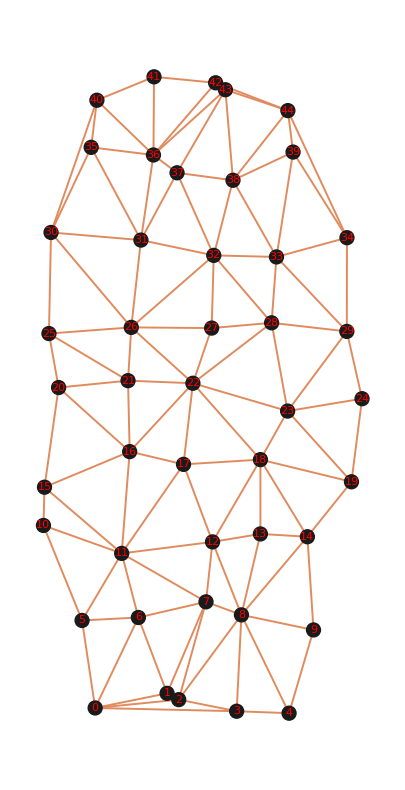

In [6]:
fig, ax = plt.subplots(figsize=(6, 10))

active_test = {"8"}

nx.draw_networkx_edges(G2, pos2, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
nx.draw_networkx_nodes(G2, pos2, ax=ax, node_color=["#20C4C7" if n in active_test else NODE_COLOR for n in G2.nodes()], node_size=100)
nx.draw_networkx_labels(G2, pos2, ax=ax, font_size=8, font_color="red")

print(G2.nodes())

ax.set_aspect("equal")
ax.axis("off")
plt.show()

Star seed = b5_s0
Initial active nodes = 2


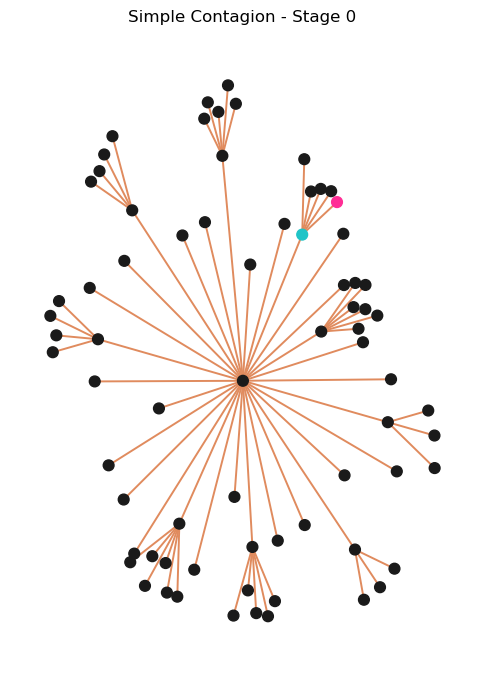

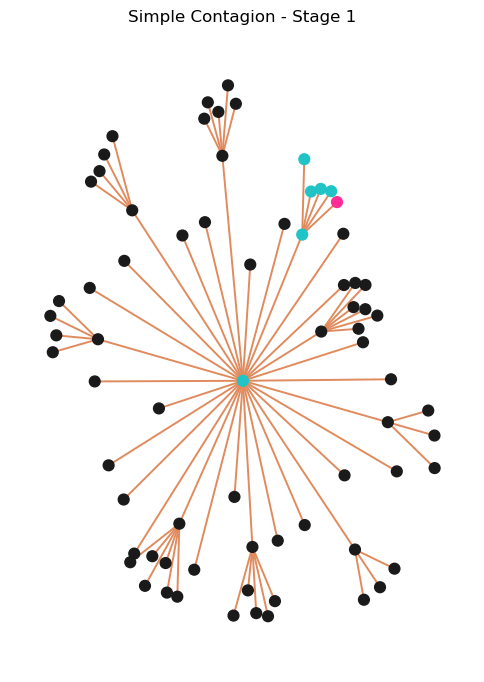

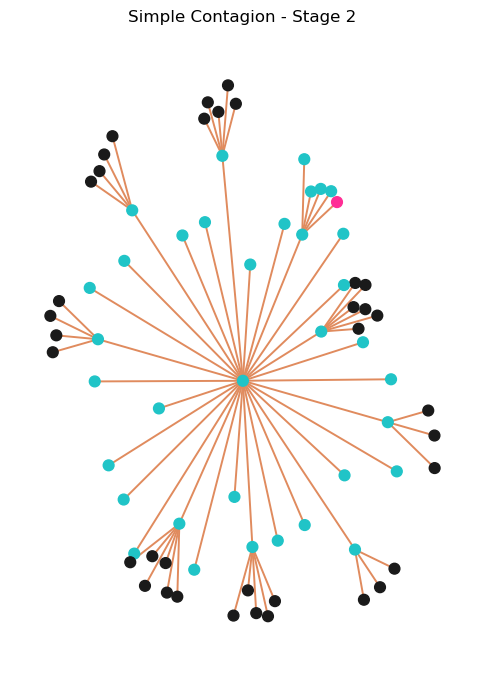

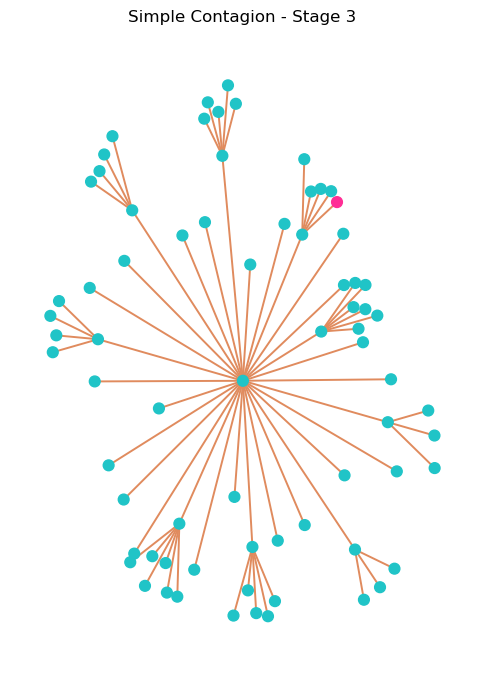

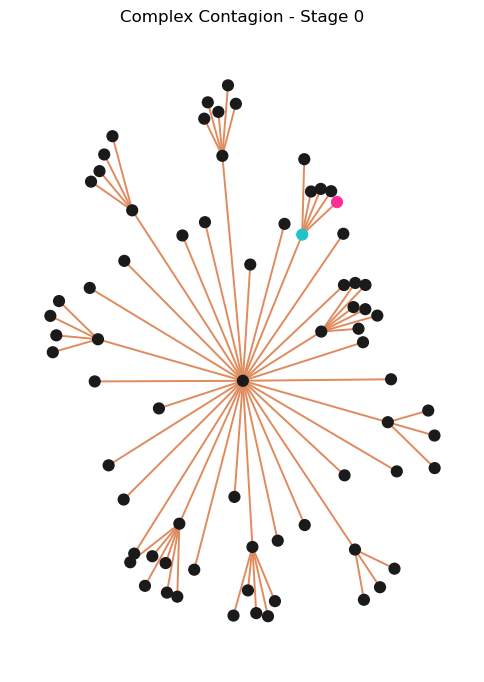

Simple animation saved: /mnt/f/test/star_simple_contagion.gif
Complex animation saved: /mnt/f/test/star_complex_contagion.gif

Simple Contagion: steps = 3 | active nodes = 72
Complex Contagion: steps = 0 | active nodes = 2


In [11]:
# ============================================================
# انتخاب گره اولیه
# ============================================================
v = "b5_s0"

initial_active = {v}
initial_active.update(G1.neighbors(v))

print("Star seed =", v)
print("Initial active nodes =", len(initial_active))

# ============================================================
# Simple Contagion
# ============================================================
active = set(initial_active)
simple_stages = [set(initial_active)]

while True:
    new_nodes = set()

    for node in G1.nodes():
        if node in active:
            continue

        if any(neighbor in active for neighbor in G1.neighbors(node)):
            new_nodes.add(node)

    if not new_nodes:
        break

    active.update(new_nodes)
    simple_stages.append(new_nodes)

simple_steps = len(simple_stages) - 1
simple_active_nodes = len(active)

simple_stage_dir = os.path.join(OUTPUT_DIR, "simple_stages")
os.makedirs(simple_stage_dir, exist_ok=True)

for stage in range(len(simple_stages)):
    active_now = set().union(*simple_stages[:stage + 1])

    fig, ax = plt.subplots(figsize=(6, 10))
    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G1.nodes()]

    nx.draw_networkx_edges(G1, pos1, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    nx.draw_networkx_nodes(G1, pos1, ax=ax, node_color=colors, node_size=60)

    ax.set_title(f"Simple Contagion - Stage {stage}")
    ax.set_aspect("equal")
    ax.axis("off")

    path = os.path.join(simple_stage_dir, f"star_simple_stage_{stage:02d}.png")
    fig.savefig(path, dpi=200, facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close(fig)
# ============================================================
# انیمیشن Simple
# ============================================================
fig, ax = plt.subplots(figsize=(6, 10))

def update_simple(frame):
    ax.clear()
    active_now = set().union(*simple_stages[:frame + 1])

    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G1.nodes()]
    nx.draw_networkx_edges(G1, pos1, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    nx.draw_networkx_nodes(G1, pos1, ax=ax, node_color=colors, node_size=NODE_SIZE)

    ax.set_title(f"Simple Contagion - Stage {frame}")
    ax.set_aspect("equal")
    ax.axis("off")

animation_simple = FuncAnimation(fig, update_simple, frames=len(simple_stages), interval=1000, repeat=True)

simple_path = os.path.join(OUTPUT_DIR, "star_simple_contagion.gif")
animation_simple.save(simple_path, writer=PillowWriter(fps=1))
plt.close(fig)

# ============================================================
# Complex Contagion
# ============================================================
Threshold_complex = 2

active = set(initial_active)
complex_stages = [set(initial_active)]

while True:
    new_nodes = set()

    for node in G1.nodes():
        if node in active:
            continue

        active_neighbors = sum(neighbor in active for neighbor in G1.neighbors(node))

        if active_neighbors >= Threshold_complex:
            new_nodes.add(node)

    if not new_nodes:
        break

    active.update(new_nodes)
    complex_stages.append(new_nodes)

complex_steps = len(complex_stages) - 1
complex_active_nodes = len(active)

complex_stage_dir = os.path.join(OUTPUT_DIR, "complex_stages")
os.makedirs(complex_stage_dir, exist_ok=True)

for stage in range(len(complex_stages)):
    active_now = set().union(*complex_stages[:stage + 1])

    fig, ax = plt.subplots(figsize=(6, 10))
    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G1.nodes()]

    nx.draw_networkx_edges(G1, pos1, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    nx.draw_networkx_nodes(G1, pos1, ax=ax, node_color=colors, node_size=60)

    ax.set_title(f"Complex Contagion - Stage {stage}")
    ax.set_aspect("equal")
    ax.axis("off")

    path = os.path.join(complex_stage_dir, f"star_complex_stage_{stage:02d}.png")
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")

    plt.show()
    plt.close(fig)
# ============================================================
# انیمیشن Complex
# ============================================================

fig, ax = plt.subplots(figsize=(6, 10))

def update_complex(frame):
    ax.clear()
    active_now = set().union(*complex_stages[:frame + 1])

    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G1.nodes()]
    nx.draw_networkx_edges(G1, pos1, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    nx.draw_networkx_nodes(G1, pos1, ax=ax, node_color=colors, node_size=NODE_SIZE)

    ax.set_title(f"Complex Contagion - Stage {frame}")
    ax.set_aspect("equal")
    ax.axis("off")

animation_complex = FuncAnimation(fig, update_complex, frames=len(complex_stages), interval=1000, repeat=True)

complex_path = os.path.join(OUTPUT_DIR, "star_complex_contagion.gif")
animation_complex.save(complex_path, writer=PillowWriter(fps=1))
plt.close(fig)

# ============================================================
# مقایسه نهایی
# ============================================================
print("Simple animation saved:", simple_path)
print("Complex animation saved:", complex_path)
print("\n==============================")
print("Simple Contagion: steps =", simple_steps, "| active nodes =", len(set().union(*simple_stages)))
print("Complex Contagion: steps =", complex_steps, "| active nodes =", len(set().union(*complex_stages)))
#print("Complex stage 0 =", complex_stages[0])

Initial active nodes = [7, 8, 11, 12, 13, 17, 18]
Number of initial active nodes = 7
Threshold_complex = 2


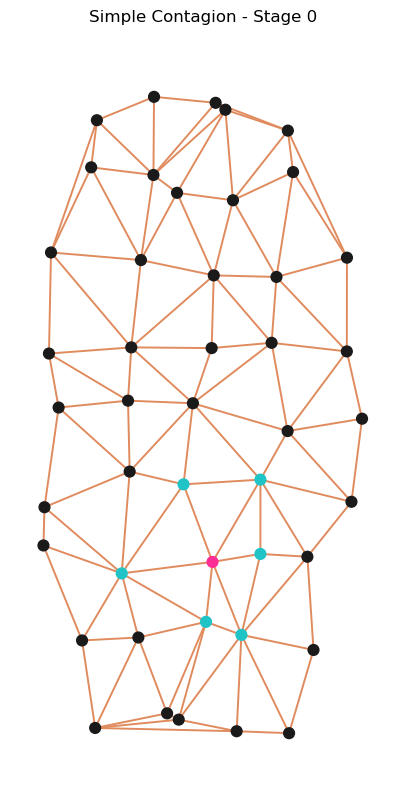

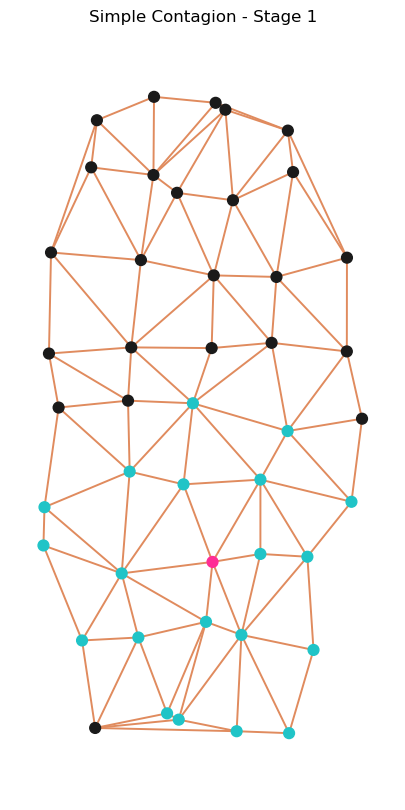

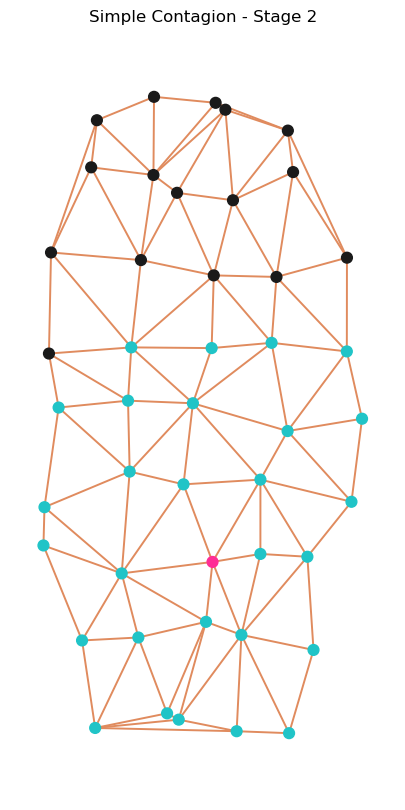

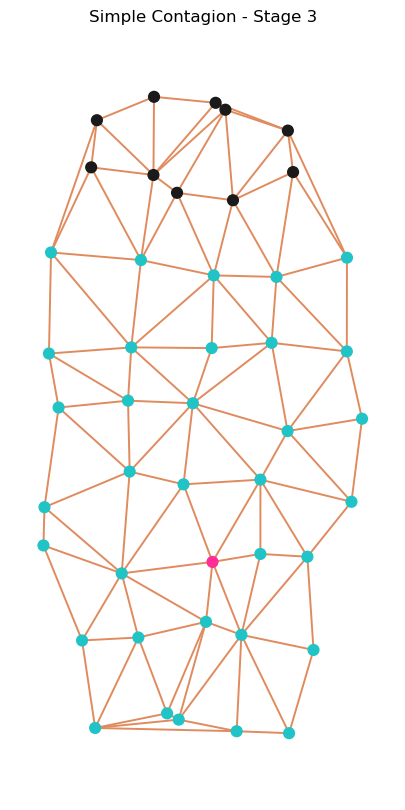

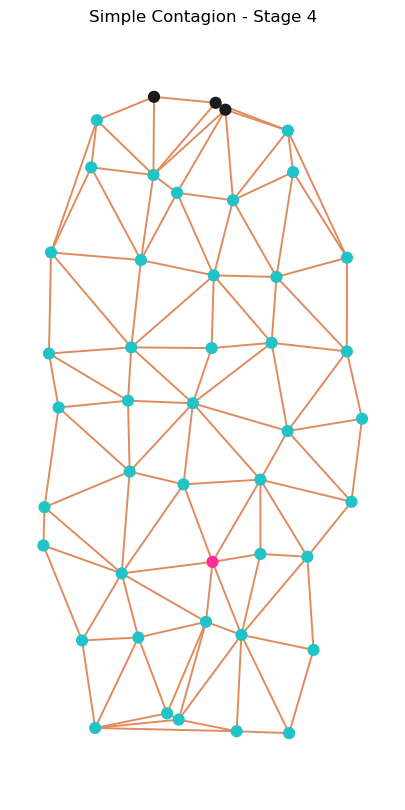

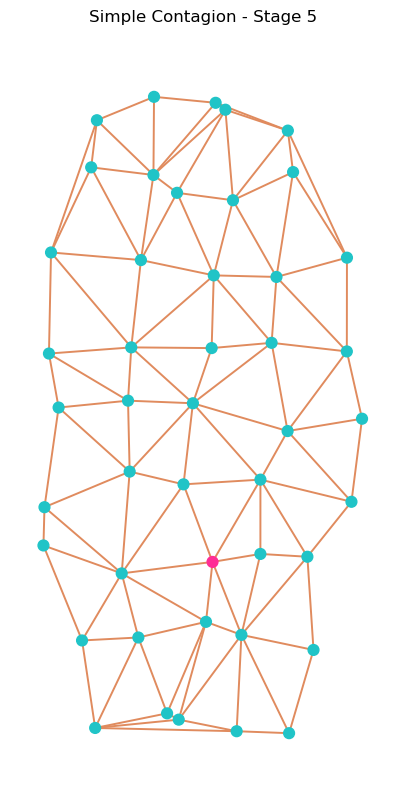

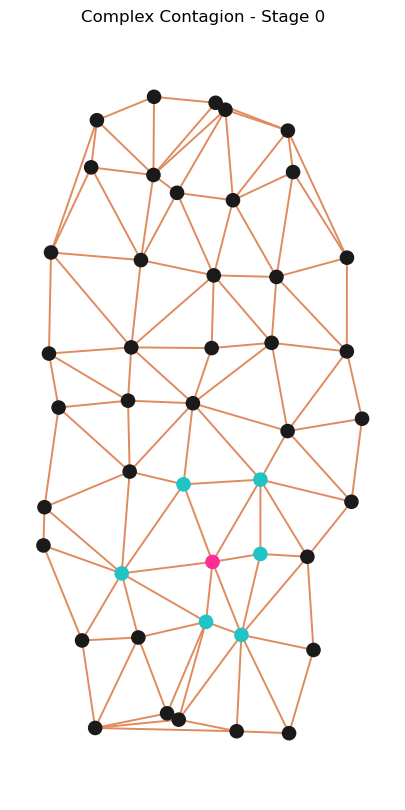

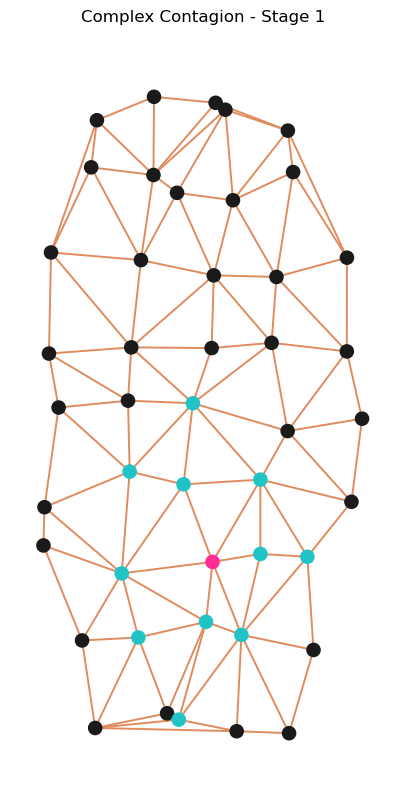

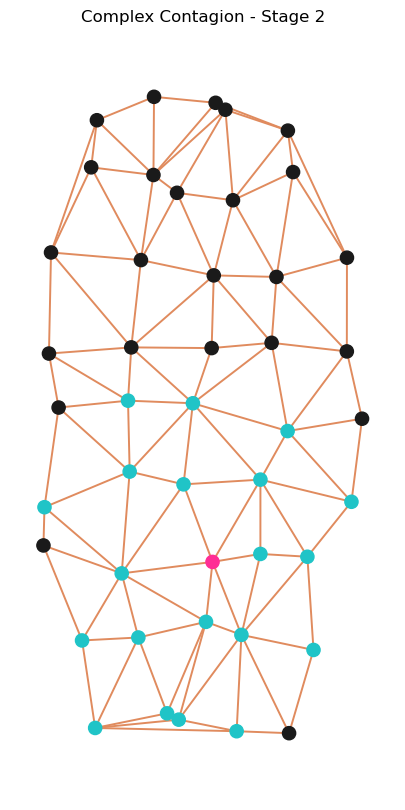

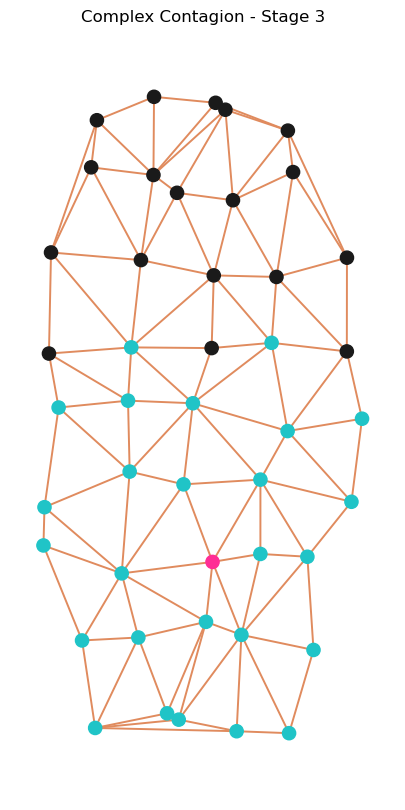

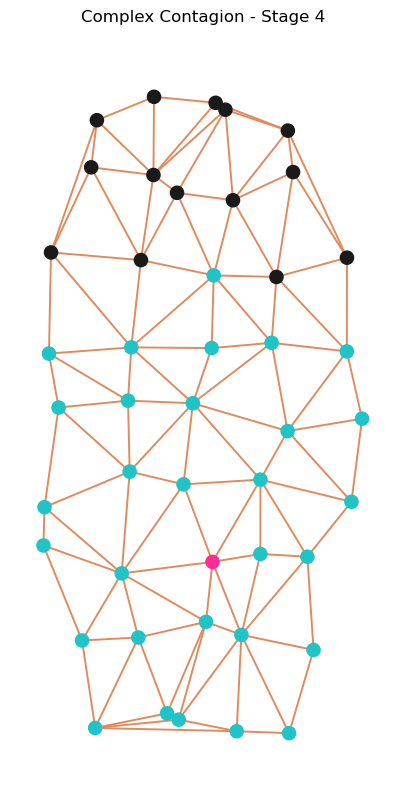

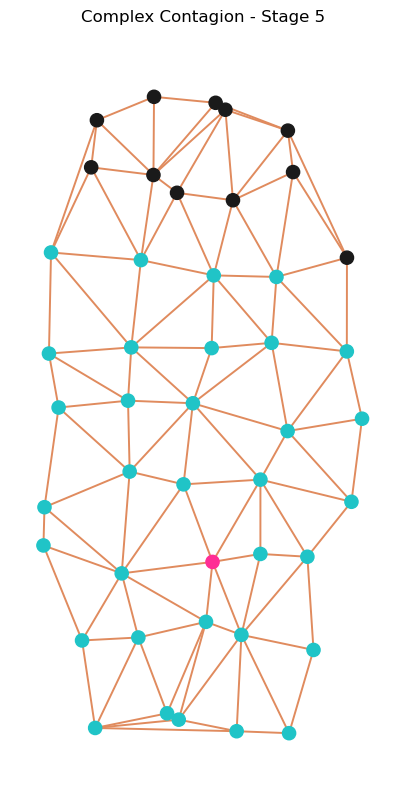

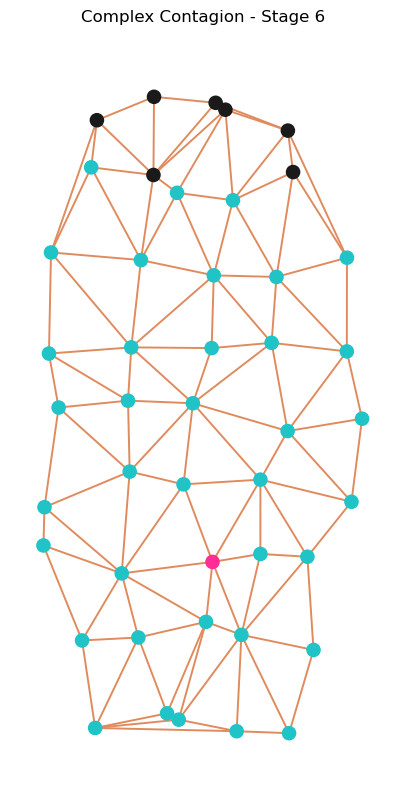

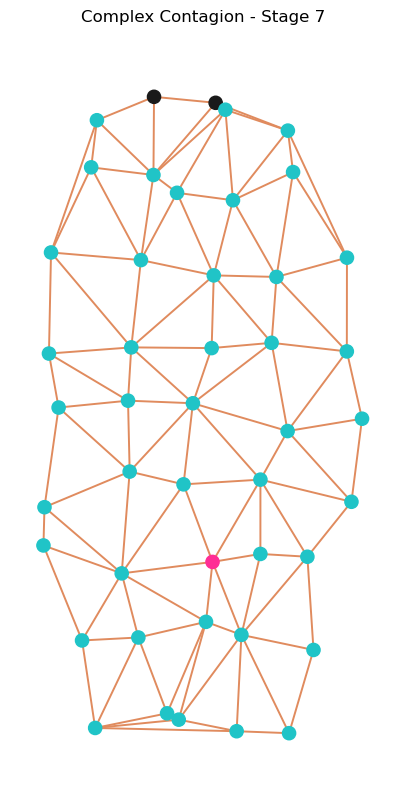

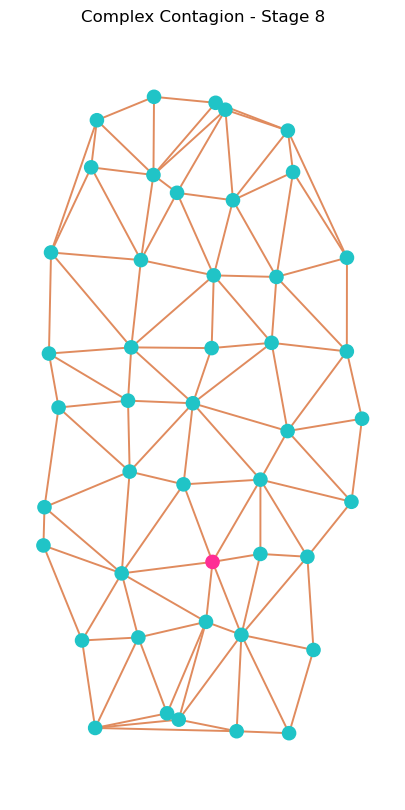

Simple animation saved: /mnt/f/test/mesh_simple_contagion.gif
Complex animation saved: /mnt/f/test/mesh_complex_contagion.gif

Simple Contagion: steps = 5 | active nodes = 45
Complex Contagion: steps = 8 | active nodes = 45


In [12]:
# ============================================================
# انتخاب seed اولیه
# ============================================================
v = 12 

initial_active = {v}
initial_active.update(G2.neighbors(v))

print("Initial active nodes =", sorted(initial_active))
print("Number of initial active nodes =", len(initial_active))
print("Threshold_complex =", 2)

# ============================================================
# Simple Contagion
# ============================================================

active = set(initial_active)
simple_stages = [set(initial_active)]

while True:
    new_nodes = set()

    for node in G2.nodes():
        if node in active:
            continue

        if any(neighbor in active for neighbor in G2.neighbors(node)):
            new_nodes.add(node)

    if not new_nodes:
        break

    active.update(new_nodes)
    simple_stages.append(new_nodes)

simple_steps = len(simple_stages) - 1
simple_active_nodes = len(active)

simple_stage_dir = os.path.join(OUTPUT_DIR, "simple_stages")
os.makedirs(simple_stage_dir, exist_ok=True)

for stage in range(len(simple_stages)):
    active_now = set().union(*simple_stages[:stage + 1])

    fig, ax = plt.subplots(figsize=(6, 10))
    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G2.nodes()]

    nx.draw_networkx_edges(G2, pos2, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    nx.draw_networkx_nodes(G2, pos2, ax=ax, node_color=colors, node_size=60)

    ax.set_title(f"Simple Contagion - Stage {stage}")
    ax.set_aspect("equal")
    ax.axis("off")

    path = os.path.join(simple_stage_dir, f"mesh_simple_stage_{stage:02d}.png")
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
# ============================================================
# انیمیشن Simple Contagion
# ============================================================
fig, ax = plt.subplots(figsize=(6, 10))

def update_simple(frame):
    ax.clear()

    active_now = set()
    for i in range(frame + 1):
        active_now.update(simple_stages[i])

    nx.draw_networkx_edges(G2, pos2, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G2.nodes()]
    nx.draw_networkx_nodes(G2, pos2, ax=ax, node_color=colors, node_size=NODE_SIZE)

    ax.set_title(f"Simple Contagion - Stage {frame}")
    ax.set_aspect("equal")
    ax.axis("off")

animation_simple = FuncAnimation(
    fig, update_simple, frames=len(simple_stages), interval=1000, repeat=True)

simple_path = os.path.join(OUTPUT_DIR, "mesh_simple_contagion.gif")
animation_simple.save(simple_path, writer=PillowWriter(fps=1))
plt.close(fig)

# ============================================================
# Complex Contagion
# ============================================================
Threshold_complex = 2

active = set(initial_active)
complex_stages = [set(initial_active)]

while True:
    new_nodes = set()

    for node in G2.nodes():
        if node in active:
            continue

        active_neighbors = sum(
            neighbor in active for neighbor in G2.neighbors(node))

        if active_neighbors >= Threshold_complex:
            new_nodes.add(node)

    if not new_nodes:
        break

    active.update(new_nodes)
    complex_stages.append(new_nodes)

complex_steps = len(complex_stages) - 1
complex_active_nodes = len(active)

complex_stage_dir = os.path.join(OUTPUT_DIR, "complex_stages")
os.makedirs(complex_stage_dir, exist_ok=True)

for stage in range(len(complex_stages)):
    active_now = set().union(*complex_stages[:stage + 1])

    fig, ax = plt.subplots(figsize=(6, 10))
    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G2.nodes()]
    nx.draw_networkx_edges(G2, pos2, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    nx.draw_networkx_nodes(G2, pos2, ax=ax, node_color=colors, node_size=NODE_SIZE)

    ax.set_title(f"Complex Contagion - Stage {stage}")
    ax.set_aspect("equal")
    ax.axis("off")

    path = os.path.join(complex_stage_dir, f"mesh_complex_stage_{stage:02d}.png")
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")

    plt.show()
    plt.close(fig)
# ============================================================
# انیمیشن Complex Contagion
# ============================================================
fig, ax = plt.subplots(figsize=(6, 10))

def update_complex(frame):
    ax.clear()

    active_now = set()
    for i in range(frame + 1):
        active_now.update(complex_stages[i])

    nx.draw_networkx_edges(G2, pos2, ax=ax, edge_color=EDGE_COLOR, width=EDGE_WIDTH)
    colors = ["#FF2D95" if n == v else "#20C4C7" if n in active_now else NODE_COLOR for n in G2.nodes()]    
    nx.draw_networkx_nodes(G2, pos2, ax=ax, node_color=colors, node_size=NODE_SIZE)

    ax.set_title(f"Complex Contagion - Stage {frame}")
    ax.set_aspect("equal")
    ax.axis("off")

animation_complex = FuncAnimation(
    fig, update_complex, frames=len(complex_stages), interval=1000, repeat=True)

complex_path = os.path.join(OUTPUT_DIR, "mesh_complex_contagion.gif")
animation_complex.save(complex_path, writer=PillowWriter(fps=1))
plt.close(fig)

# ============================================================
# مقایسه نهایی
# ============================================================
#print("\n")
print("Simple animation saved:", simple_path)
print("Complex animation saved:", complex_path)
print("\n==============================")
print("Simple Contagion: steps =", simple_steps, "| active nodes =", simple_active_nodes)
print("Complex Contagion: steps =", complex_steps, "| active nodes =", complex_active_nodes)